# Task 3 — Distributions and relationships (Penguins)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "legend.frameon": False, "font.size": 10, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def finish(fig, title, subtitle=None, note=None, name=None):
    fig.tight_layout()
    tr = lambda y: offset_copy(fig.transFigure, fig=fig, y=y, units="points")
    if subtitle:
        fig.text(0.01, 1, subtitle, va="bottom", fontsize=10, color=INK_SOFT, transform=tr(4))
    fig.text(0.01, 1, title, va="bottom", fontsize=14, fontweight="bold", color=INK,
             transform=tr(22 if subtitle else 6))
    if note:
        fig.text(0.01, 0, note, va="top", fontsize=9, color=INK_MUTED, transform=tr(-4))
    if name:
        fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)
    plt.show()

In [2]:
peng = pd.read_csv(DATA / "penguins.csv")
print(peng.shape)
peng.isna().sum()

(344, 7)


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [3]:
peng[peng.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


11 rows have gaps. 2 penguins (rows 3 and 339) have no measurements at all and no sex, and 9 more have all
the measurements but no sex.

My decision:
- The 2 empty penguins are dropped everywhere — there's nothing to plot.
- The 9 with missing sex are kept for charts 1–3 (they don't use sex) and dropped only for chart 4.
- I don't guess/impute sex.

In [4]:
measured = peng.dropna(subset=["body_mass_g"])
with_sex = measured.dropna(subset=["sex"])
print("measured:", len(measured), " with sex:", len(with_sex))

SPECIES = ["Adelie", "Chinstrap", "Gentoo"]
SP_COL = dict(zip(SPECIES, [BLUE, ORANGE, AQUA]))

measured: 342  with sex: 333


## 1. Distribution of body mass

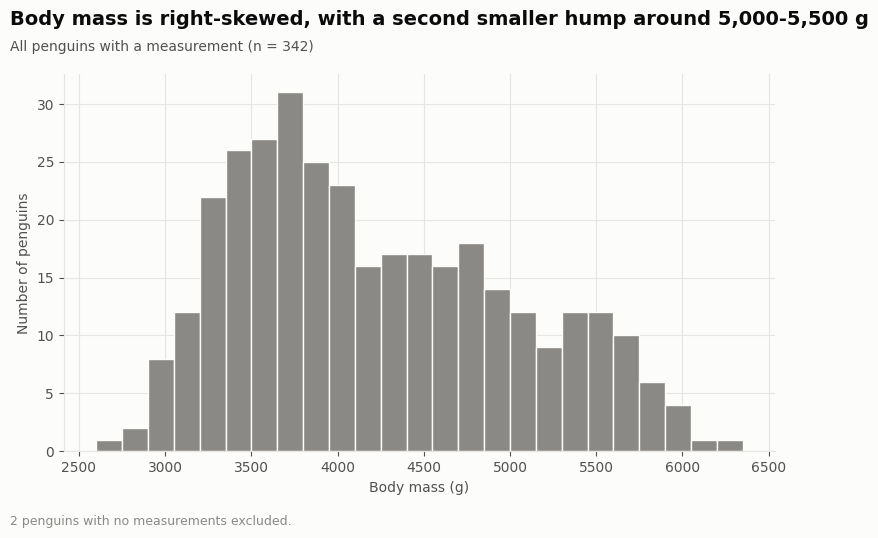

In [5]:
bins = np.arange(2600, 6500, 150)

fig, ax = plt.subplots()
ax.hist(measured["body_mass_g"], bins=bins, color=INK_MUTED, edgecolor=SURFACE)
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Number of penguins")

finish(fig, "Body mass is right-skewed, with a second smaller hump around 5,000-5,500 g",
       f"All penguins with a measurement (n = {len(measured)})",
       "2 penguins with no measurements excluded.", name="task3_mass_hist")

**Why this chart:** one numeric variable and the question is its shape → histogram. Grey because there are
no groups yet.

It's not one clean bell curve. Most penguins are around 3,500–4,000 g, then there's a long right tail with
what looks like a second, smaller hump near 5,000–5,500 g. That usually means two groups mixed together.

## 2. Split by species

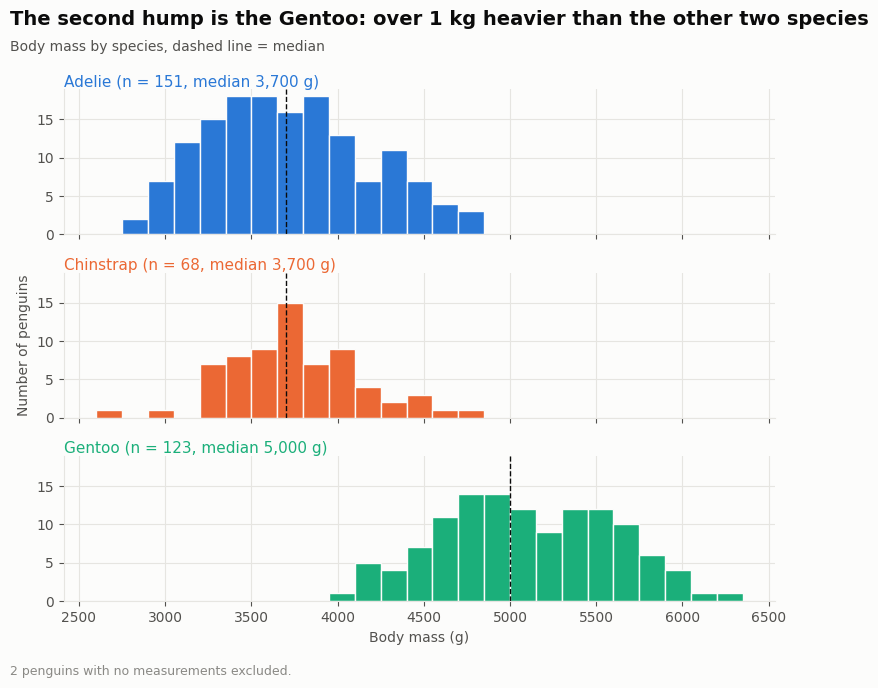

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True, sharey=True)
for ax, sp in zip(axes, SPECIES):
    d = measured[measured["species"] == sp]
    ax.hist(d["body_mass_g"], bins=bins, color=SP_COL[sp], edgecolor=SURFACE)
    ax.axvline(d["body_mass_g"].median(), color=INK, linewidth=1, linestyle="--")
    ax.set_title(f"{sp} (n = {len(d)}, median {d['body_mass_g'].median():,.0f} g)", color=SP_COL[sp], pad=2)
axes[-1].set_xlabel("Body mass (g)")
axes[1].set_ylabel("Number of penguins")

finish(fig, "The second hump is the Gentoo: over 1 kg heavier than the other two species",
       "Body mass by species, dashed line = median",
       "2 penguins with no measurements excluded.", name="task3_mass_by_species")

**Why this chart:** still a distribution, but now by group. I used small multiples stacked with the same
x-axis instead of overlapping histograms, because Adelie and Chinstrap overlap almost completely and would
hide each other.

Yes, this explains it. Adelie and Chinstrap are both around 3,700 g and make up the big hump. Gentoo are a
separate, heavier group around 5,000 g, which is the second hump and the "skew" from step 1. The overall
shape was really a mix of two different populations.

## 3. Bill length vs bill depth

In [7]:
r_all = measured["bill_length_mm"].corr(measured["bill_depth_mm"])
r_sp = measured.groupby("species").apply(lambda d: d["bill_length_mm"].corr(d["bill_depth_mm"]), include_groups=False)
print(f"all penguins r = {r_all:.2f}")
r_sp.round(2)

all penguins r = -0.24


species
Adelie       0.39
Chinstrap    0.65
Gentoo       0.64
dtype: float64

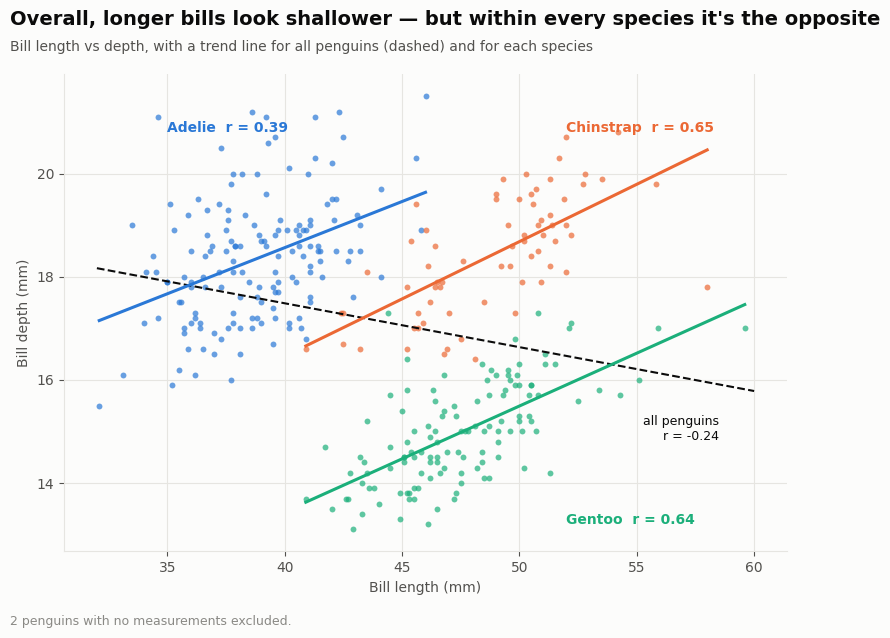

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))

xs = np.linspace(32, 60, 50)
b = np.polyfit(measured["bill_length_mm"], measured["bill_depth_mm"], 1)
ax.plot(xs, np.polyval(b, xs), color=INK, linestyle="--", linewidth=1.5)
ax.text(58.5, np.polyval(b, 58.5) - 0.6, f"all penguins\nr = {r_all:.2f}", color=INK, fontsize=9, ha="right", va="top")

label_pos = {"Adelie": (35, 20.8), "Chinstrap": (52, 20.8), "Gentoo": (52, 13.2)}
for sp in SPECIES:
    d = measured[measured["species"] == sp]
    ax.scatter(d["bill_length_mm"], d["bill_depth_mm"], s=18, color=SP_COL[sp], alpha=0.7, linewidth=0)
    b = np.polyfit(d["bill_length_mm"], d["bill_depth_mm"], 1)
    x = np.linspace(d["bill_length_mm"].min(), d["bill_length_mm"].max(), 20)
    ax.plot(x, np.polyval(b, x), color=SP_COL[sp], linewidth=2.2)
    ax.text(*label_pos[sp], f"{sp}  r = {r_sp[sp]:.2f}", color=SP_COL[sp], fontweight="bold")

ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")

finish(fig, "Overall, longer bills look shallower — but within every species it's the opposite",
       "Bill length vs depth, with a trend line for all penguins (dashed) and for each species",
       "2 penguins with no measurements excluded.", name="task3_simpsons")

**Why this chart:** two numeric variables → scatter. Colour by species because species is exactly what
changes the story, and I labelled the groups on the chart instead of a legend.

**What's going on:** across all penguins the trend is negative (r = −0.24), but inside each species it is
positive (0.39, 0.65, 0.64) — penguins with longer bills also have deeper bills, like you'd expect from
bigger birds. The reason is that species is a hidden third variable. Gentoo have long but shallow bills, and
Adelie have short but deep ones. So when you mix everyone together, the line mostly connects "short and
deep" Adelie to "long and shallow" Gentoo and it slopes down, even though no single species behaves that way.

This is **Simpson's paradox**: a trend that appears in the combined data reverses (or disappears) when you
split it into groups. It's the best reason to always check your groups separately before trusting a
correlation.

## 4. Average body mass by species and sex

In [9]:
avg = with_sex.groupby(["species", "sex"])["body_mass_g"].mean().unstack()
counts = with_sex.groupby(["species", "sex"]).size().unstack()
avg.round(0)

sex,FEMALE,MALE
species,,
Adelie,3369.0,4043.0
Chinstrap,3527.0,3939.0
Gentoo,4680.0,5485.0


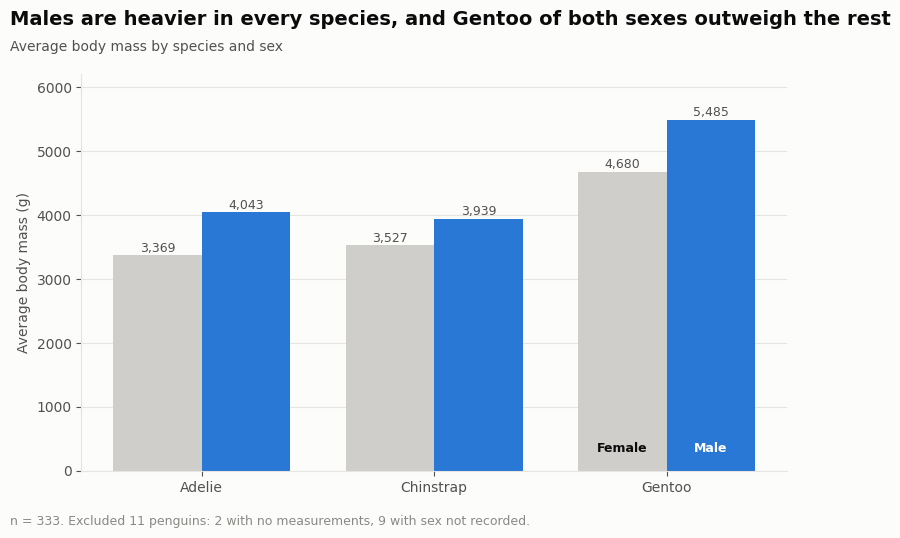

In [10]:
x = np.arange(len(SPECIES))
w = 0.38

fig, ax = plt.subplots()
for i, (sex, color) in enumerate([("FEMALE", QUIET), ("MALE", BLUE)]):
    vals = avg.loc[SPECIES, sex]
    bars = ax.bar(x + (i - 0.5) * w, vals, width=w, color=color)
    for bar, v, n in zip(bars, vals, counts.loc[SPECIES, sex]):
        ax.text(bar.get_x() + w / 2, v + 60, f"{v:,.0f}", ha="center", fontsize=9, color=INK_SOFT)
    ax.text(x[-1] + (i - 0.5) * w, 300, sex.title(), ha="center", color=INK if sex == "FEMALE" else "white",
            fontsize=9, fontweight="bold")

ax.set_xticks(x, SPECIES)
ax.set_ylim(0, 6200)
ax.set_ylabel("Average body mass (g)")
ax.grid(axis="x", visible=False)

finish(fig, "Males are heavier in every species, and Gentoo of both sexes outweigh the rest",
       "Average body mass by species and sex",
       f"n = {len(with_sex)}. Excluded 11 penguins: 2 with no measurements, 9 with sex not recorded.",
       name="task3_mass_species_sex")

**Why this chart:** comparing an average across two categories (species and sex) → grouped bar chart. Bars
start at 0 so heights are fair to compare. Only 2 colours (female grey, male blue) and I put the labels
inside the Gentoo bars instead of a legend. The footnote says which penguins were left out.

Males are heavier than females in all three species (about 400–800 g more), and Gentoo are the heaviest
by a lot for both sexes.